In [29]:
## Time Evolution under the Heisenberg Hamiltonian

In [30]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
from qiskit.quantum_info import SparsePauliOp
from scipy.linalg import expm

In [31]:
qc = QuantumCircuit(2)
qc.h(0)

psi0 = Statevector.from_instruction(qc)

In [32]:
# Define Hamiltonian H = J(Sx​Sx​ + Sy​Sy ​+ Sz​Sz​)
J = 1.0  # coupling constant

Sx = np.array([[0, 1], [1, 0]]) / 2
Sy = np.array([[0, -1j], [1j, 0]]) / 2
Sz = np.array([[1, 0], [0, -1]]) / 2

H = J * (np.kron(Sx, Sx) + np.kron(Sy, Sy) + np.kron(Sz, Sz))

In [33]:
P00 = []
P01 = []
P10 = []
P11 = []

time = np.linspace(0,10,100)
# Time Evolution operator U(t) = exp(-iHt) 
for t in time:
    U = expm(-1j * H * t)
    psi = Statevector(U @ psi0.data)
    probs = psi.probabilities()
    P00.append(probs[0])
    P01.append(probs[1])
    P10.append(probs[2])
    P11.append(probs[3])

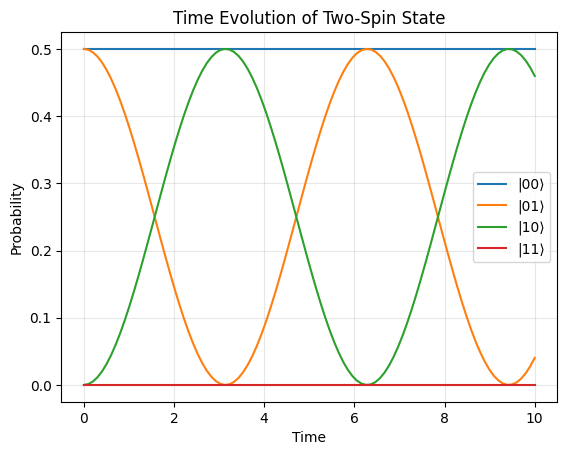

In [34]:
plt.plot(time, P00, label="|00⟩")
plt.plot(time, P01, label="|01⟩")
plt.plot(time, P10, label="|10⟩")
plt.plot(time, P11, label="|11⟩")

plt.xlabel("Time")
plt.ylabel("Probability")
plt.title("Time Evolution of Two-Spin State")

plt.grid(alpha=0.3)
plt.legend()

plt.show()